# Stage 5: final evaluation and reusable scoring

This notebook **reads executed artifacts**, it does not select or retrain models.
The frozen Stage 4 selection retains the same 27 checkout-simulation predictors,
64-tree forests and exact illustrative 5:1 policy were retained. Tutorial 8
development diagnostics preceded the protected final holdout evaluation.

Targets: lead days among eventually delivered orders; any recorded 1–2 star
review among reviewed orders. Missing reviews are unknown, not negative-class
examples. Catalogue/payment/seller snapshot availability at checkout remains an
assumption. A mixed-time grouped holdout does not measure future temporal drift.

Use the pinned setup in notebook 05. Build the development supplement with `python -m src.models.tutorial8`, then verify it with `python -m src.models.verify_tutorial8 --report artifacts/metrics/stage5_tutorial8_internal_verification.json`. Existing run/report paths must first be preserved outside the active output tree; never overwrite them.

For this previously evaluated frozen protocol, final reproduction requires `python -m src.models.finalize --replay`. The original access receipt is mandatory and remains unchanged; a separate reproduction receipt is reserved before fits. Ordinary finalization refuses prior test access. Changed inputs/models/policy or duplicate attempts are rejected. These are reproduced results, not a fresh independent test estimate. Do not delete either receipt to force a rebuild.

Verify final results with `python -m src.models.verify_stage5`; recreate the six-order example with `python -m src.models.scoring_demo`. Scoring is also available through `python -m src.models.score --help`. Read-only published-checkpoint inspection is `python -m src.models.stage5_checkpoint`; it checks final results fully and development diagnostics compactly, without omitted curve coordinates/fold models.
Do not rerun final fitting to improve test results. Reloading the same immutable
model/predictions is verification, not a fresh selection experiment.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/models/finalize.py').exists())
assert (ROOT / 'src/models').exists()
import sys
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
FINAL = ROOT / 'artifacts/metrics/stage5-final-v1'
DIAGNOSTIC = ROOT / 'artifacts/metrics/stage5-tutorial8-v1'
def read_json(path): return json.loads(path.read_text())
def read_csv(path): return pd.read_csv(path, float_precision='round_trip')
manifest = read_json(FINAL / 'run_manifest.json')
assert manifest['holdout_evaluated'] is True and manifest['fit_count'] == 2
display(pd.Series(manifest['environment'], name='Executed runtime'))
print('Evaluation mode:', manifest.get('evaluation_mode', 'original protected evaluation'))
print('Independent test estimate:', manifest.get('independent_test_estimate', True))

joblib           1.6.0
matplotlib      3.11.2
numpy            2.4.2
pandas           2.3.3
python          3.13.9
scikit-learn     1.9.0
scipy           1.18.1
Name: Executed runtime, dtype: object

Evaluation mode: frozen_holdout_reproduction_not_independent_test
Independent test estimate: False


## 1. Freeze and training lineage

Final preprocessing was fitted only on each task's eligible development rows.
The model bundles include original-unit schema, learned preprocessing, training
feature statistics, versions/hashes and policy. IDs, outcomes and eligibility
flags are not predictors. Exact threshold precision is part of the contract.

In [2]:
selection = read_json(ROOT / 'artifacts/metrics/stage4-selection-v1/selection_record.json')
policy = read_json(ROOT / 'artifacts/models/classification/stage5-final-v1/decision_policy.json')
display(pd.DataFrame(read_json(FINAL / 'final_fit_evidence.json')))
print('Predictors:', len(selection['features']))
print('Exact primary policy:', policy['comparison'], repr(policy['threshold']))
print('Policy cost assumption:', policy['cost_assumption'])
print('Original protected evaluation receipt:', read_json(ROOT / 'artifacts/metrics/stage5_holdout_access.json')['state'])
if manifest.get('reproduction_receipt_file'):
    print('Separate reproduction receipt:', read_json(ROOT / 'artifacts/metrics' / manifest['reproduction_receipt_file'])['state'])

,groups,n,seconds,task,training_group_ids_sha256,training_order_ids_sha256,warnings
0,74626,77139,30.451631,regression,07ae122f33b64bd27164ac3abba5577ae5b1afa80bd19a...,2d88d343eaf52cab13490ae5ae20213f1260dfca694491...,[]
1,76279,78938,24.227465,classification,e9fc63743d8966b04073ba29ff247bbcf1704253e1905d...,f11b40f91d4a76c021dcb8f31eafa9873ca13b2adde9c5...,[]


Predictors: 27
Exact primary policy: >= 0.16387042604339028
Policy cost assumption: illustrative, not measured Olist business cost
Original protected evaluation receipt: evaluated_and_published
Separate reproduction receipt: evaluated_and_published


## 2. Tutorial 8 diagnostics before testing

Training subsets preserve complete customer groups and are nested within saved
training folds. Validation customers never move. Training AP falls and validation
AP rises with size, but a substantial gap remains. This suggests persistent
generalization limitations; it does not guarantee that more data will solve them.
Bands are descriptive fold SD, not confidence intervals. The OOF overlay uses
identical orders; pooled AP need not equal mean CV AP. CART rules explain the
baseline tree, not the selected forest or causal effects.

training_n             \
                                                       mean        std   
fraction_training_groups partition                                       
0.25                     training_resubstitution    15768.0  12.000000   
                         validation                 15768.0  12.000000   
0.50                     training_resubstitution    31564.4  11.523888   
                         validation                 31564.4  11.523888   
1.00                     training_resubstitution    63150.4   0.894427   
                         validation                 63150.4   0.894427   

                                                 average_precision            \
                                                              mean       std   
fraction_training_groups partition                                             
0.25                     training_resubstitution          0.504606  0.002716   
                         validation                       0.295603  0.002257   
0.50                     training_resubstitution          0.477528  0.003755   
                         validation                       0.304824  0.002306   
1.00                     training_resubstitution          0.451450  0.001758   
                         validation                       0.311769  0.002933   

                                                   roc_auc            
                                                      mean       std  
fraction_training_groups partition                                    
0.25                     training_resubstitution  0.848258  0.003009  
                         validation               0.646377  0.008027  
0.50                     training_resubstitution  0.811786  0.001654  
                         validation               0.656760  0.008543  
1.00                     training_resubstitution  0.782070  0.003264  
                         validation               0.664615  0.010299

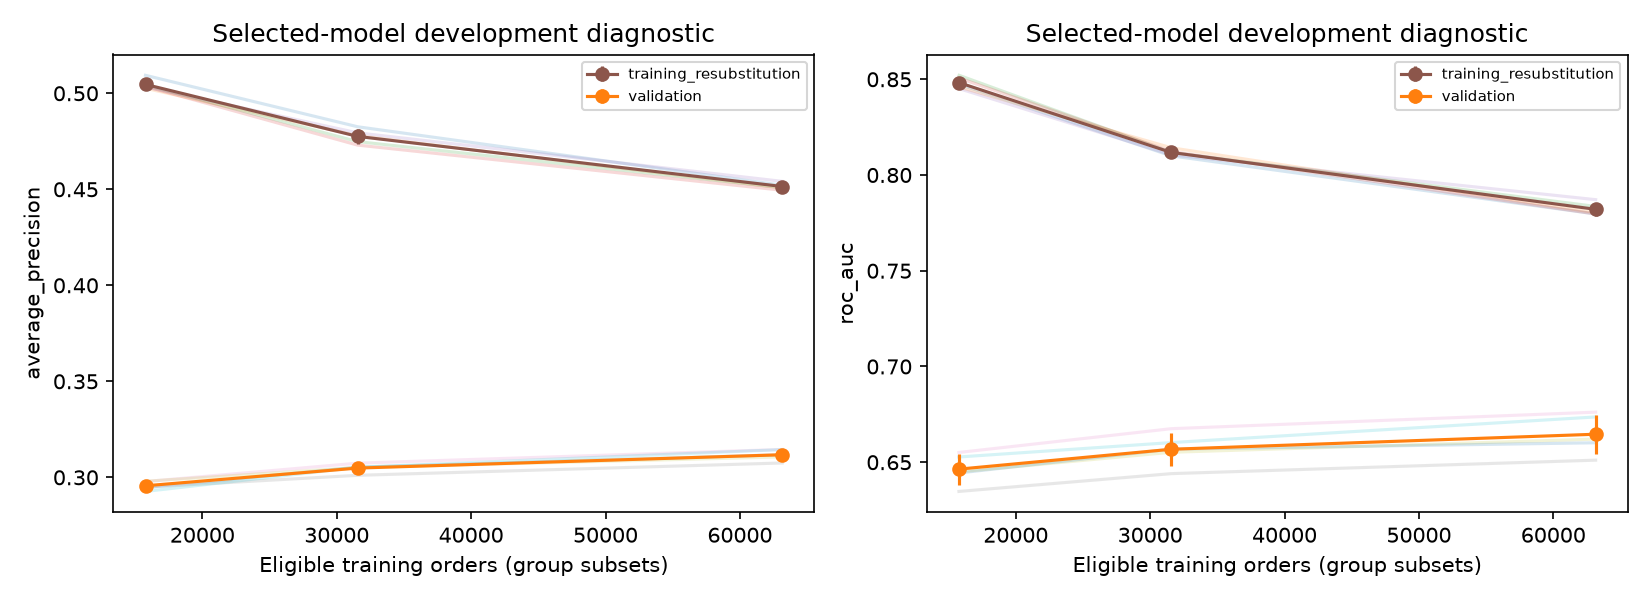

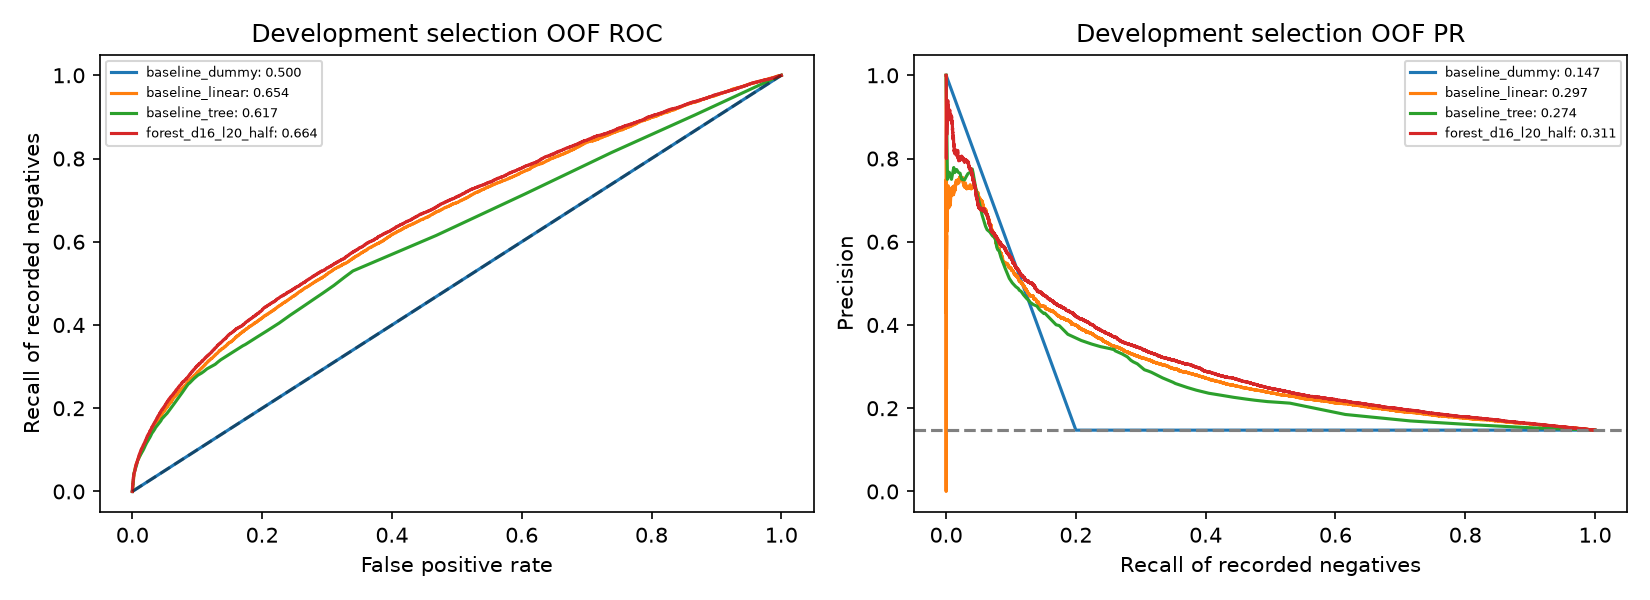

,feature,node,operator,threshold,transformed_value
0,numeric__missingindicator_distance_missing_fra...,0,<=,0.500000,0.000000
1,numeric__n_items,1,<=,1.500000,1.000000
2,categorical__customer_state_RJ,2,<=,0.500000,0.000000
3,numeric__distance_km_max,3,<=,1409.677124,21.684565
4,categorical__purchase_month_3,4,>,0.500000,1.000000


Explained model: baseline CART, not selected forest leaf: 6 P(class 1): 0.15067222994900326


In [3]:
learning = read_csv(DIAGNOSTIC / 'learning_curve.csv')
display(learning.groupby(['fraction_training_groups', 'partition'])[['training_n', 'average_precision', 'roc_auc']].agg(['mean', 'std']))
display(Image(filename=str(DIAGNOSTIC / 'learning_curves.png')))
display(Image(filename=str(DIAGNOSTIC / 'oof_comparison.png')))
tree_path = read_json(DIAGNOSTIC / 'worked_tree_path.json')
display(pd.DataFrame(tree_path['conditions']))
print('Explained model:', tree_path['model'], 'leaf:', tree_path['leaf'], 'P(class 1):', tree_path['probability_1'])

## 3. Protected final results

AP summarizes precision–recall for the recorded-negative positive class, ROC-AUC
summarizes pairwise ranking, Brier evaluates probability error. Accuracy is
supplementary under imbalance. MAE is in days; RMSE emphasizes large errors and
R² compares squared error against variation in this cohort. No clipping, label
trimming, reweighting or test-informed model/threshold changes were applied.
The 5:1 cost is illustrative, not observed financial or intervention benefit.

In [4]:
results = read_json(FINAL / 'holdout_metrics.json')
display(pd.DataFrame({task: result['metrics'] for task, result in results.items()}).T)
display(pd.DataFrame([results['classification']['default_0_5_metrics']], index=['default 0.5']))
display(read_csv(FINAL / 'classification_per_class_report.csv'))
print('No-skill AP reference:', results['classification']['constant_score_ap_reference'])
print('Illustrative controls:', results['classification']['illustrative_controls'])

,accuracy,alert_fraction,alerts,average_precision,brier,f1_1,fn,fnr,fp,fpr,...,recall_1,roc_auc,specificity,threshold,tn,tp,mae,negative_predictions,r2,rmse
classification,0.743755,0.239676,4730,0.318458,0.116068,0.337829,1617,0.556244,3440,0.204421,...,0.443756,0.665027,0.795579,0.16387,13388,1290,NaN,NaN,NaN,NaN
regression,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4.897162,0.0,0.305337,8.310043


,accuracy,alert_fraction,alerts,average_precision,brier,f1_1,fn,fnr,fp,fpr,...,precision_1,precision_defined,prevalence,ranking_metrics_defined,recall_1,roc_auc,specificity,threshold,tn,tp
default 0.5,0.858627,0.014948,295,0.318458,0.116068,0.12867,2701,0.929137,89,0.005289,...,0.698305,True,0.147302,True,0.070863,0.665027,0.994711,0.5,16739,206


,policy,class,meaning,support,predicted_n,precision,recall,f1,threshold,precision_unavailable_reason,recall_unavailable_reason
0,default_0_5,0,recorded nonnegative review,16828,19440,0.861060,0.994711,0.923073,0.50000,NaN,NaN
1,default_0_5,1,recorded negative review,2907,295,0.698305,0.070863,0.128670,0.50000,NaN,NaN
2,frozen_policy,0,recorded nonnegative review,16828,15005,0.892236,0.795579,0.841140,0.16387,NaN,NaN
3,frozen_policy,1,recorded negative review,2907,4730,0.272727,0.443756,0.337829,0.16387,NaN,NaN


No-skill AP reference: 0.14730174816316188
Illustrative controls: {'all_alert_cost': 16828, 'assumption': 'FP=1, FN=5; not measured costs or intervention benefits', 'no_alert_cost': 14535}


## 4. Error and probability diagnostics

Residual is observed minus predicted days. Long-delay underprediction cannot be
hidden by trimming labels. Reliability bins include counts in the saved table;
rare high-score bins do not prove calibration. Confusion matrix rows are actual
classes, columns predictions. FP means an alert on a recorded nonnegative review;
FN means a missed recorded-negative review, not a measured operational outcome.

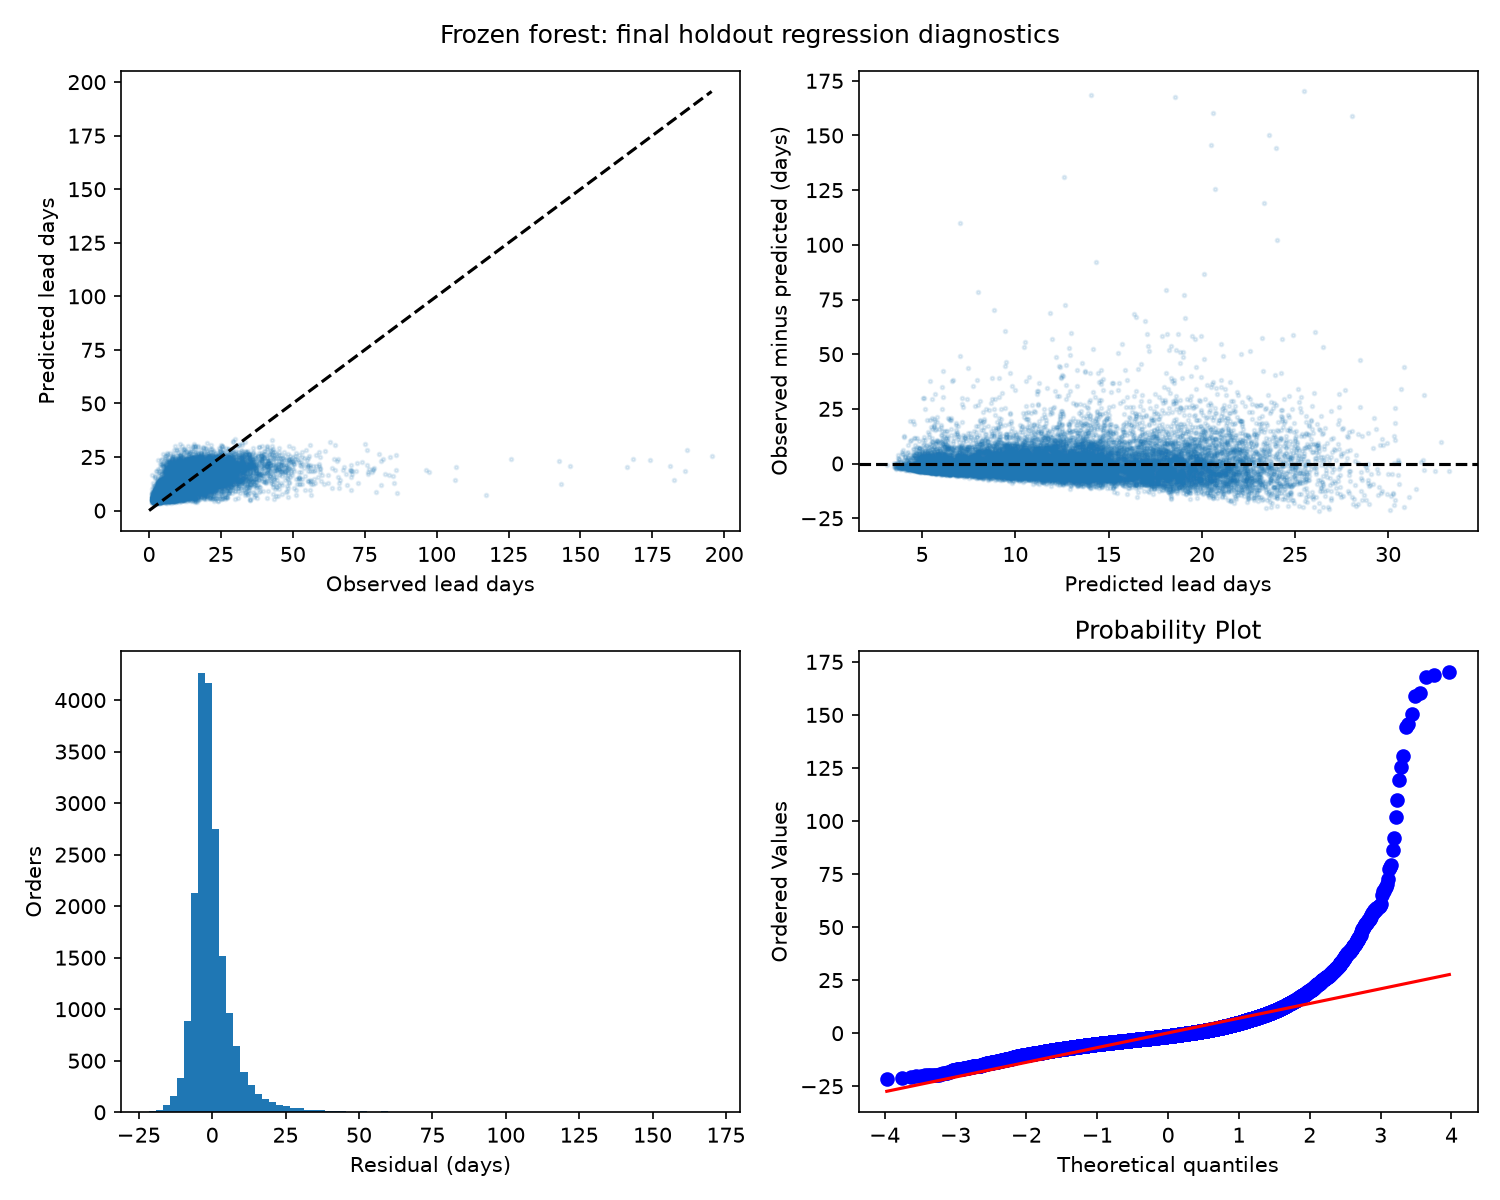

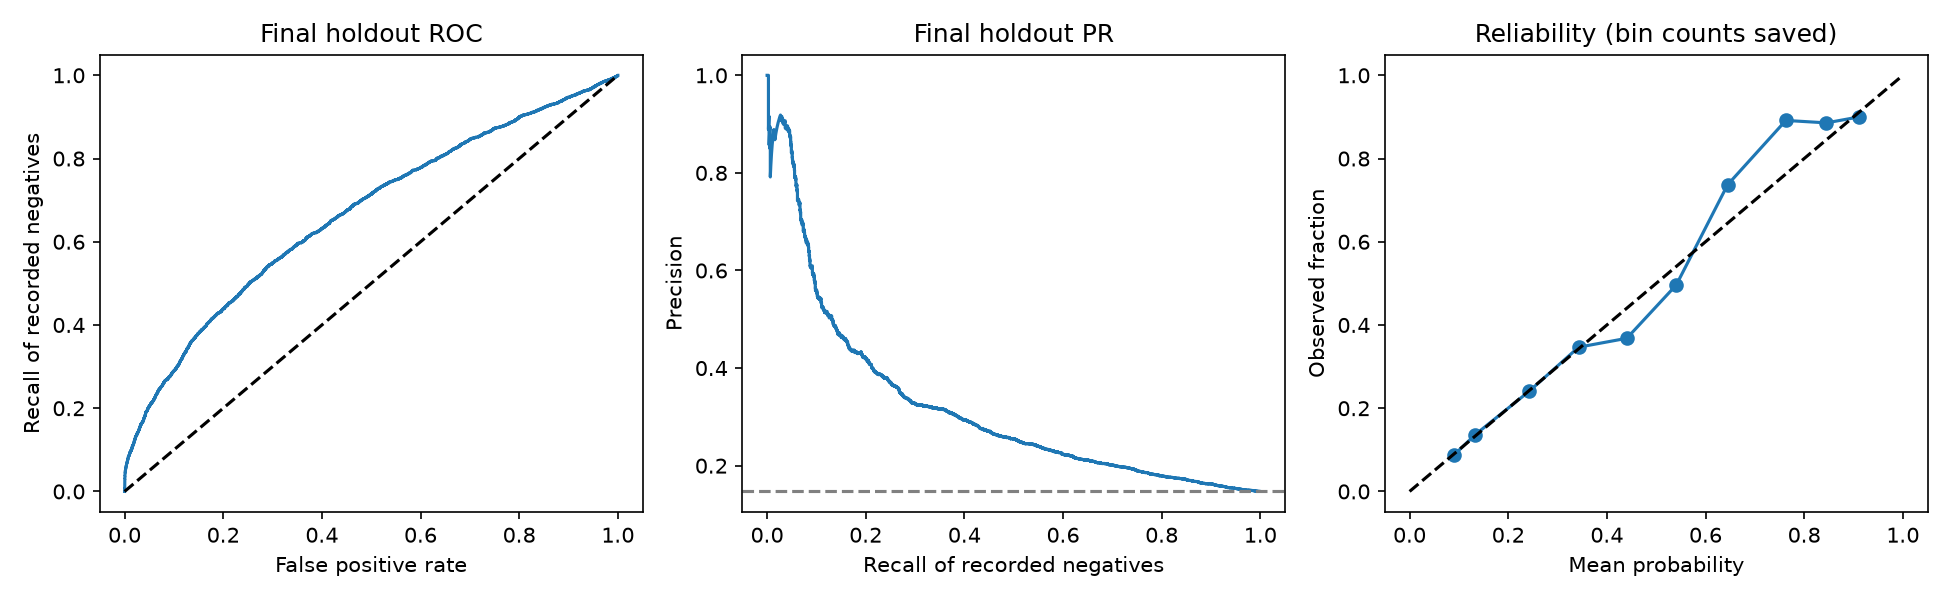

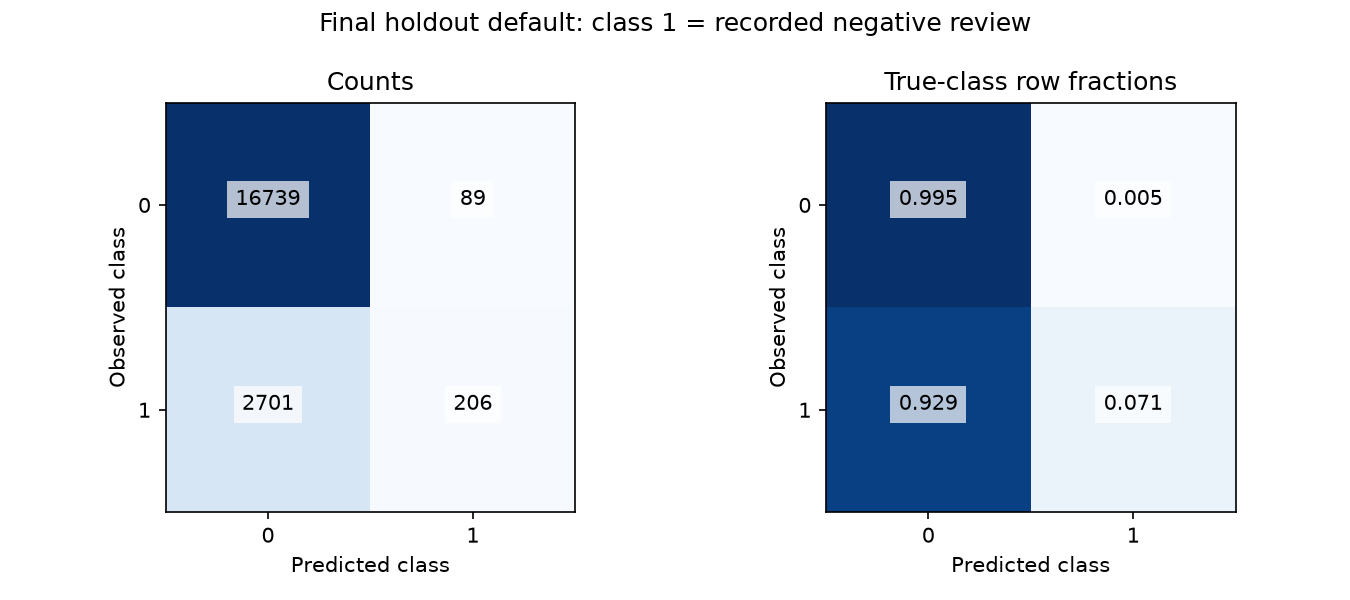

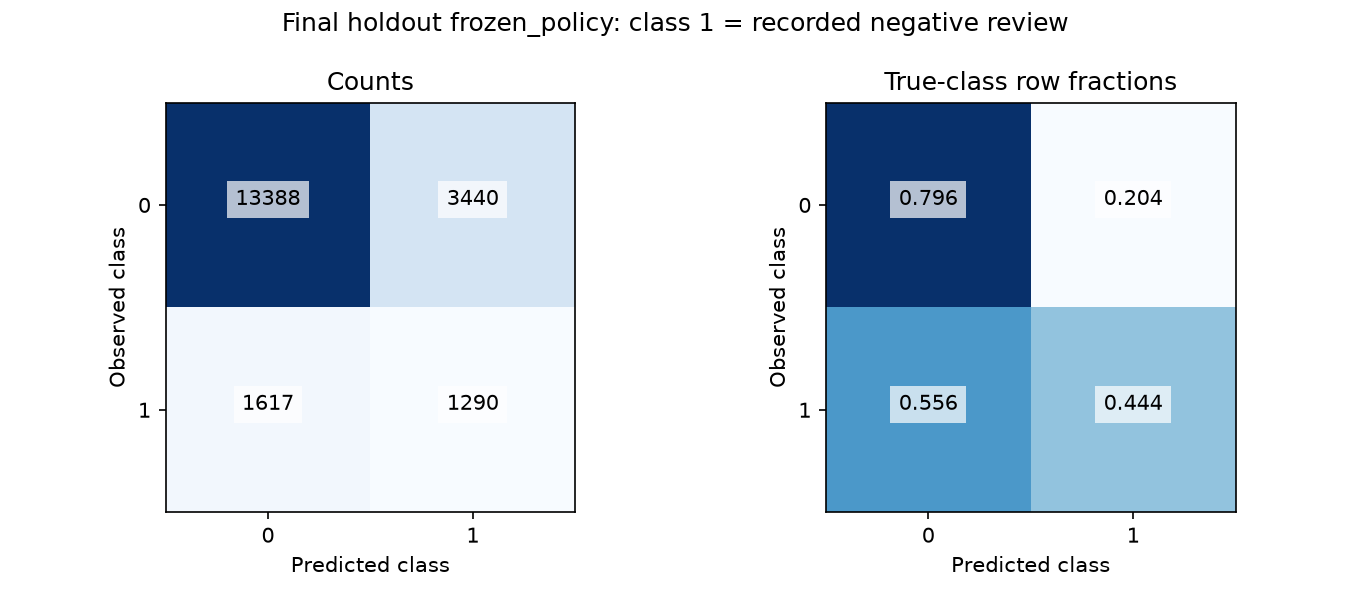

,bin,lower_inclusive,upper,n,mean_probability,observed_negative_fraction
0,0,0.0,0.1,7323,0.090132,0.087669
1,1,0.1,0.2,9268,0.133120,0.136491
2,2,0.2,0.3,1872,0.242073,0.240385
3,3,0.3,0.4,727,0.342622,0.346630
4,4,0.4,0.5,250,0.440349,0.368000
5,5,0.5,0.6,129,0.540654,0.496124
6,6,0.6,0.7,38,0.644670,0.736842
7,7,0.7,0.8,83,0.762843,0.891566
8,8,0.8,0.9,35,0.845138,0.885714
9,9,0.9,1.0,10,0.911463,0.900000


In [5]:
for name in ['regression_holdout_diagnostics.png', 'classification_holdout_curves.png', 'confusion_default.png', 'confusion_frozen_policy.png']:
    display(Image(filename=str(FINAL / name)))
display(read_csv(FINAL / 'classification_reliability.csv'))

## 5. Supported subgroup interpretation

State, basket size and observed regression-duration bands were declared before
test access. Outcomes stratified by actual duration are descriptive and cannot be
known at checkout. Read support/class counts first. Small or single-class groups
have unstable/unavailable metrics. Geography does not establish demographic
fairness. These tables cannot trigger changes to the same held-out experiment.

In [6]:
subgroups = read_csv(FINAL / 'holdout_subgroups.csv')
display(subgroups.loc[subgroups.dimension.eq('basket_size')].dropna(axis=1, how='all'))
display(subgroups.loc[subgroups.dimension.eq('observed_duration_days')].dropna(axis=1, how='all'))
display(subgroups.loc[subgroups.dimension.eq('customer_state'), ['task', 'subgroup', 'n', 'small_support_flag', 'mae', 'average_precision', 'recall_1']])

,task,dimension,subgroup,small_support_flag,n,mae,rmse,r2,negative_predictions,unavailable_reason,...,fn,tp,fpr,fnr,specificity,precision_defined,ranking_metrics_defined,alerts,illustrative_cost_5_to_1,alert_fraction
27,regression,basket_size,0,True,0,NaN,NaN,NaN,NaN,empty subgroup,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,regression,basket_size,1,False,17470,4.901300,8.266984,0.312491,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,regression,basket_size,2-3,False,1693,4.882639,8.903837,0.221492,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,regression,basket_size,4+,False,168,4.613263,6.346341,0.418153,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62,classification,basket_size,0,False,152,NaN,NaN,NaN,NaN,NaN,...,0.0,133.0,1.000000,0.000000,0.000000,True,True,152.0,19.0,1.000000
63,classification,basket_size,1,False,17705,NaN,NaN,NaN,NaN,NaN,...,1584.0,677.0,0.146335,0.700575,0.853665,True,True,2937.0,10180.0,0.165885
64,classification,basket_size,2-3,False,1700,NaN,NaN,NaN,NaN,NaN,...,32.0,419.0,0.839872,0.070953,0.160128,True,True,1468.0,1209.0,0.863529
65,classification,basket_size,4+,False,178,NaN,NaN,NaN,NaN,NaN,...,1.0,61.0,0.965517,0.016129,0.034483,True,True,173.0,117.0,0.971910


,task,dimension,subgroup,small_support_flag,n,mae,rmse,r2,negative_predictions
31,regression,observed_duration_days,0-7,False,5278,3.720408,4.618680,-7.545313,0.0
32,regression,observed_duration_days,7-14,False,7944,3.391012,4.477253,-3.883121,0.0
33,regression,observed_duration_days,14-30,False,5150,5.037149,6.316608,-1.296982,0.0
34,regression,observed_duration_days,30+,False,959,23.098241,29.904600,-1.643517,0.0


,task,subgroup,n,small_support_flag,mae,average_precision,recall_1
0,regression,AC,8,True,10.041051,NaN,NaN
1,regression,AL,70,True,7.962976,NaN,NaN
2,regression,AM,31,True,7.535914,NaN,NaN
3,regression,AP,10,True,17.931089,NaN,NaN
4,regression,BA,696,False,6.645564,NaN,NaN
5,regression,CE,240,False,8.245760,NaN,NaN
6,regression,DF,393,False,4.834720,NaN,NaN
7,regression,ES,381,False,6.074723,NaN,NaN
8,regression,GO,357,False,5.854913,NaN,NaN
9,regression,MA,132,False,6.982362,NaN,NaN


## 6. Reloaded original-unit scoring, no fitting

Use trusted local checksummed bundles. Inference needs the 27 named predictors
and a unique order ID, not labels, final status or eligibility. Missing cells
follow training imputation; unseen categories follow the saved encoder. Missing
columns/malformed numerics/duplicate IDs produce explicit invalid-row results,
not plausible defaults. Predictions outside the labelled training cohorts are
extrapolation. A hosted service and live dashboard integration remain later work.

In [7]:
from src.models.data import load_development, task_rows
from src.models.score import Scorer
from src.features.contract import PREDICTOR_ALLOWLIST
development, cv, _ = load_development(ROOT)
for task in ['regression', 'classification']:
    scorer = Scorer(ROOT / 'artifacts/models' / task / 'stage5-final-v1')
    sample = task_rows(development, cv, task).iloc[:3][['order_id'] + PREDICTOR_ALLOWLIST]
    display(scorer.score(sample))
from src.models.verify_stage5 import verify
print('Read-only final verification:', verify(FINAL, ROOT)['status'])
print('Independent Stage 5 and teammate review remain pending. Stage 6 is not executed.')

,input_row,order_id,task,model_version,feature_version,contract_version,split_version,prediction,probability_1,decision,threshold,status,error,warnings
0,0,00018f77f2f0320c557190d7a144bdd3,regression,stage5-final-v1,v1.1,v1.2,v1.1,11.642136,None,None,None,valid,None,"{""missing_predictor_cells"": []}"
1,1,000229ec398224ef6ca0657da4fc703e,regression,stage5-final-v1,v1.1,v1.2,v1.1,10.621259,None,None,None,valid,None,"{""missing_predictor_cells"": []}"
2,2,00024acbcdf0a6daa1e931b038114c75,regression,stage5-final-v1,v1.1,v1.2,v1.1,7.257059,None,None,None,valid,None,"{""missing_predictor_cells"": []}"


,input_row,order_id,task,model_version,feature_version,contract_version,split_version,prediction,probability_1,decision,threshold,status,error,warnings
0,0,00018f77f2f0320c557190d7a144bdd3,classification,stage5-final-v1,v1.1,v1.2,v1.1,0,0.105909,0,0.16387,valid,None,"{""missing_predictor_cells"": []}"
1,1,000229ec398224ef6ca0657da4fc703e,classification,stage5-final-v1,v1.1,v1.2,v1.1,0,0.092736,0,0.16387,valid,None,"{""missing_predictor_cells"": []}"
2,2,00024acbcdf0a6daa1e931b038114c75,classification,stage5-final-v1,v1.1,v1.2,v1.1,0,0.096307,0,0.16387,valid,None,"{""missing_predictor_cells"": []}"


.

.

.

...

.

.

.

----------------------------------------------------------------------
Ran 69 tests in 2.108s

OK


Read-only final verification: passed_internal_verification
Independent Stage 5 and teammate review remain pending. Stage 6 is not executed.
